Power Plant Convolutional Neural Network

In [29]:
from google.colab import files #Uploading U.S. zip file to colab
uploaded = files.upload()

Saving ds_small.zip to ds_small.zip


In [30]:
import zipfile

zip_path = "/content/ds_small.zip" #Defining a path to ZIP file in Colab environment
extract_path = "/content/dataset" #Defining an output path for ZIP contents extraction

with zipfile.ZipFile(zip_path, 'r') as zip_ref: #Unzipping and extracting contents for use
    zip_ref.extractall(extract_path)

In [31]:
import os #Importing os library for file system interaction
print(os.listdir("/content/dataset")) #Ensusing that the directory is mapped to contents extracted into dataset folder

['ds_small']


In [32]:
img_dir = "/content/dataset/ds_small/img" #Defining the image directly specifically and checking contents
print(os.listdir(img_dir)[:5])

['ls8_4246_MN_WND.tif.jpg', 'ls8_5646_NJ_SUN.tif.jpg', 'naip_7487_TX_WND.tif.jpg', 'ls8_1480_CA_WAT.tif.jpg', 'naip_6193_NY_RFO.tif.jpg']


In [33]:
import pandas as pd #Importing pandas library for dataframe construction

TARGET_CLASSES = ["NG", "SUN", "WAT", "WND"] #Defining top four classes to keep

image_paths = []
labels = []

for fname in os.listdir(img_dir): #Extracting fuel labels from file names
    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
        parts = fname.split("_")
        raw_label = parts[-1]
        label = raw_label.split(".")[0]

        if label in TARGET_CLASSES:
            image_paths.append(os.path.join(img_dir, fname))
            labels.append(label)

df = pd.DataFrame({ #Creating a dataframe with images and labels extracted from file names
    "image_path": image_paths,
    "label": labels
})

print("Total usable images:", len(df)) #Getting descriptive information for created pandas dataset
print("Classes found:", sorted(df["label"].unique()))
print(df["label"].value_counts().sort_index())

label_map = { #Renaming fuel labels for readability
    "NG": "Natural Gas",
    "SUN": "Solar",
    "WAT": "Hydro",
    "WND": "Wind"
}

df["label"] = df["label"].map(label_map) #Mapping the labels into the dataframe


df.head()

Total usable images: 6310
Classes found: ['NG', 'SUN', 'WAT', 'WND']
label
NG     2320
SUN    1700
WAT    1376
WND     914
Name: count, dtype: int64


,image_path,label
0,/content/dataset/ds_small/img/ls8_4246_MN_WND....,Wind
1,/content/dataset/ds_small/img/ls8_5646_NJ_SUN....,Solar
2,/content/dataset/ds_small/img/naip_7487_TX_WND...,Wind
3,/content/dataset/ds_small/img/ls8_1480_CA_WAT....,Hydro
4,/content/dataset/ds_small/img/ls8_4059_MI_NG.t...,Natural Gas


In [34]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split( #Creating a training and validation set for training (we will not need a test set with this data)
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=33
)

print("Train size:", len(train_df)) #Getting information about plant type distributions in training and validation sets
print("Val size:", len(val_df))
print("\nTrain counts:")
print(train_df["label"].value_counts().sort_index())
print("\nVal counts:")
print(val_df["label"].value_counts().sort_index())

Train size: 5048
Val size: 1262

Train counts:
label
Hydro          1101
Natural Gas    1856
Solar          1360
Wind            731
Name: count, dtype: int64

Val counts:
label
Hydro          275
Natural Gas    464
Solar          340
Wind           183
Name: count, dtype: int64


**Model 1: Basic CNN**

In [35]:
#Creating an image generator which normalizes the data and feeds it to the CNN during training
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224) #Defining image size
batch_size = 32 #Defining batch size for training and feeding data to the model
all_classes = sorted(["Natural Gas", "Solar", "Hydro", "Wind"])

train_datagen = ImageDataGenerator( #Normalizing and augmenting images
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator( #Normalizing validation data
    rescale=1.0 / 255
)

train_gen = train_datagen.flow_from_dataframe( #Creating an image flow for efficient training
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=all_classes,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe( #Creating an image flow for efficient validation
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=all_classes,
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Number of classes:", len(train_gen.class_indices))

Found 5048 validated image filenames belonging to 4 classes.
Found 1262 validated image filenames belonging to 4 classes.
Class indices: {'Hydro': 0, 'Natural Gas': 1, 'Solar': 2, 'Wind': 3}
Number of classes: 4


In [36]:
#Building a basic CNN from scratch layer by layer
from tensorflow.keras import layers, models

num_classes = len(all_classes)

model = models.Sequential([ #Building model 1
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"), #ReLU is introducing nonlinearity into the model
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy", #Used for classification tasks, assigns probabilities to different classes
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,884 (37.49 MB)

 Trainable params: 9,826,884 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#Run model 1 an early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 81s 455ms/step - accuracy: 0.4033 - loss: 1.2897 - val_accuracy: 0.3978 - val_loss: 1.2585
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 62s 391ms/step - accuracy: 0.4788 - loss: 1.1631 - val_accuracy: 0.4707 - val_loss: 1.1704
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 62s 395ms/step - accuracy: 0.5145 - loss: 1.1042 - val_accuracy: 0.5293 - val_loss: 1.0444
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 63s 396ms/step - accuracy: 0.5200 - loss: 1.0858 - val_accuracy: 0.5230 - val_loss: 1.1093
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 65s 411ms/step - accuracy: 0.5523 - loss: 1.0380 - val_accuracy: 0.6038 - val_loss: 0.9489
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 63s 400ms/step - accuracy: 0.5870 - loss: 1.0009 - val_accuracy: 0.6220 - val_loss: 0.9290
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 64s 403ms/step - accuracy: 0.5943 - loss: 0.9784 - val_accuracy: 0.6395 - val_loss: 0.9306
Epoch 8/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 64s 406ms/step - accuracy: 0.6006 - loss: 0

In [38]:
val_loss, val_acc = model.evaluate(val_gen) #Finding validation loss and accuracy for 'model'
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7021 - loss: 0.7491
Validation Loss: 0.7491
Validation Accuracy: 0.7021


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step


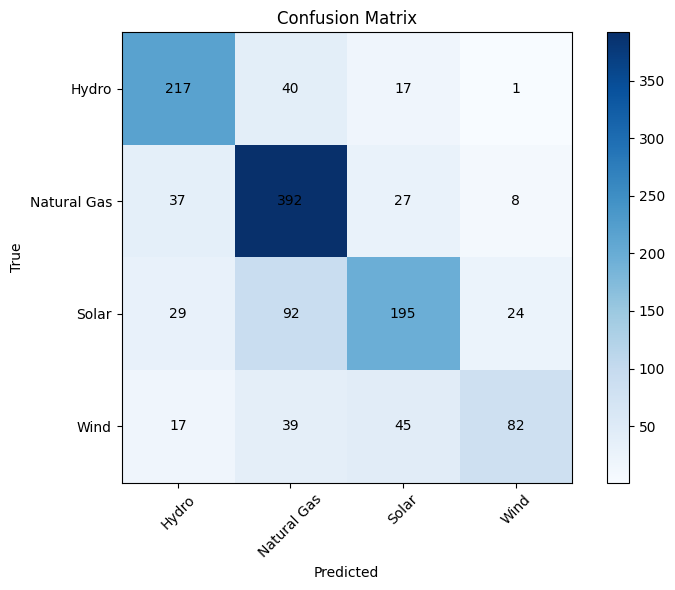

              precision    recall  f1-score   support

       Hydro       0.72      0.79      0.75       275
 Natural Gas       0.70      0.84      0.76       464
       Solar       0.69      0.57      0.62       340
        Wind       0.71      0.45      0.55       183

    accuracy                           0.70      1262
   macro avg       0.70      0.66      0.67      1262
weighted avg       0.70      0.70      0.69      1262



In [39]:
#Creating a confusion matrix to assess the validation of 'model' on unseen U.S. data
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

val_gen.reset()
pred_probs = model.predict(val_gen)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = val_gen.classes

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(all_classes)), all_classes, rotation=45)
plt.yticks(range(len(all_classes)), all_classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print(classification_report(true_labels, pred_labels, target_names=all_classes))

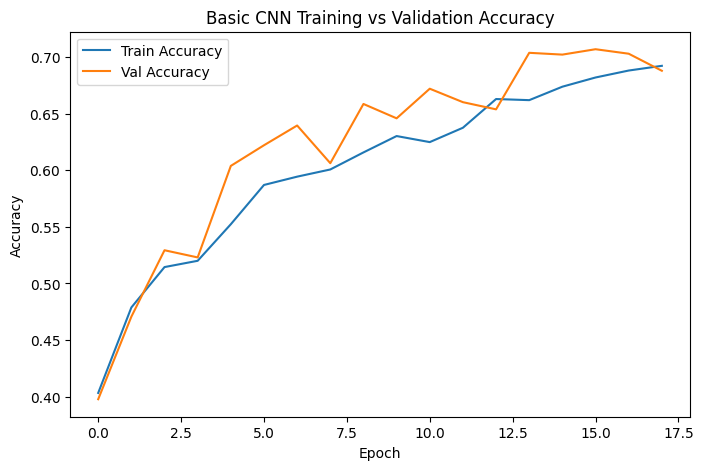

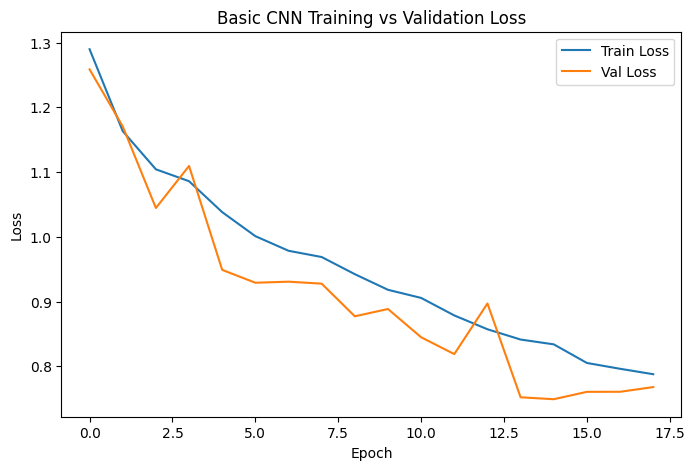

In [40]:
#Plotting validation and training accuracy and loss to monitor model performance during training
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Basic CNN Training vs Validation Loss")
plt.legend()
plt.show()

**Model 2: Frozen ResNet-50, Pretrained on ImageNet**

In [41]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

img_size = (224, 224) #Defining image size
batch_size = 32 #Defining batch size
all_classes = sorted(["Natural Gas", "Solar", "Hydro", "Wind"])
num_classes = len(all_classes)

train_datagen_resnet = ImageDataGenerator( #Normalizing and augmenting images
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen_resnet = ImageDataGenerator( #Normalizing validation data
    preprocessing_function=preprocess_input
)

train_gen_resnet = train_datagen_resnet.flow_from_dataframe( #Creating an image flow for efficient training
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=all_classes,
    shuffle=True
)

val_gen_resnet = val_datagen_resnet.flow_from_dataframe( #Creating an image flow for efficient validation
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=all_classes,
    shuffle=False
)

base_model = ResNet50( #Defining the base model as pre-trained ResNet-50
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False #Freezing the ResNet backbone for more efficient training

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model2 = models.Model(inputs, outputs) #Defining 'model2' as the base model + custom layers with ReLU and softmax activation functions

model2.compile( #Compiling the model, defining the optimizer, function, and performance metric
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping( #Defining early stopping with a patience of 3 epoch and restoration of peak parameters
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history2 = model2.fit( #Training the model using the training and validation generators
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=50,
    callbacks=[early_stop]
)

Found 5048 validated image filenames belonging to 4 classes.
Found 1262 validated image filenames belonging to 4 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 98s 528ms/step - accuracy: 0.6179 - loss: 0.9558 - val_accuracy: 0.6775 - val_loss: 0.7902
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 67s 421ms/step - accuracy: 0.6959 - loss: 0.7665 - val_accuracy: 0.6767 - val_loss: 0.7908
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 66s 416ms/step - accuracy: 0.7183 - loss: 0.6985 - val_accuracy: 0.7060 - val_loss: 0.7159
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 70s 441ms/step - accuracy: 0.7328 - loss: 0.6831 - val_accuracy: 0.7203 - val_loss: 0.6692
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 67s 427ms/step - accuracy: 0.7591 - loss: 0.6371 - val_accuracy: 0.7433 - val_loss: 0.6393
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 66s 416ms/step - accuracy: 0.7651 - loss: 0.6137 - val_accuracy: 0.7401 - val_loss: 0.6509
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 6

In [42]:
val_loss, val_acc = model2.evaluate(val_gen_resnet) #Evaluating the validation loss and accuracy of the model
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.7512 - loss: 0.6206
Validation Loss: 0.6206
Validation Accuracy: 0.7512


40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 206ms/step


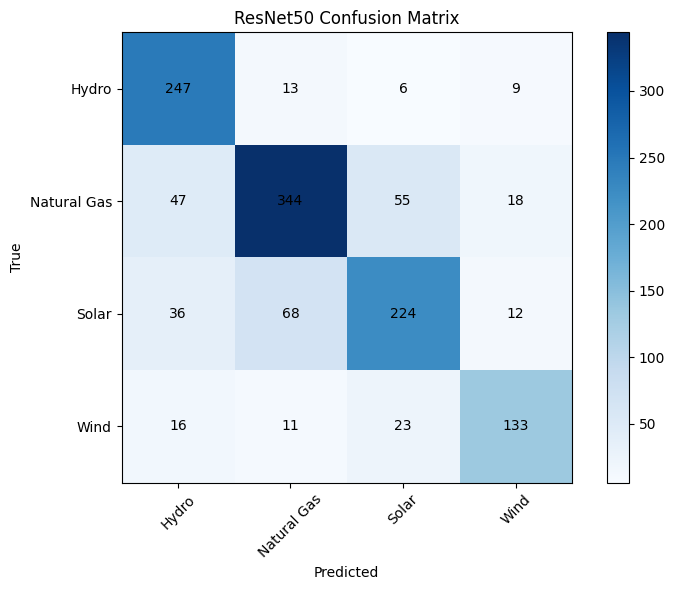

              precision    recall  f1-score   support

       Hydro       0.71      0.90      0.80       275
 Natural Gas       0.79      0.74      0.76       464
       Solar       0.73      0.66      0.69       340
        Wind       0.77      0.73      0.75       183

    accuracy                           0.75      1262
   macro avg       0.75      0.76      0.75      1262
weighted avg       0.75      0.75      0.75      1262



In [43]:
#Building a confusion matrix for 'model2' to assess performance visually
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

val_gen_resnet.reset()
pred_probs = model2.predict(val_gen_resnet)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = val_gen_resnet.classes

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(all_classes)), all_classes, rotation=45)
plt.yticks(range(len(all_classes)), all_classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

print(classification_report(true_labels, pred_labels, target_names=all_classes))

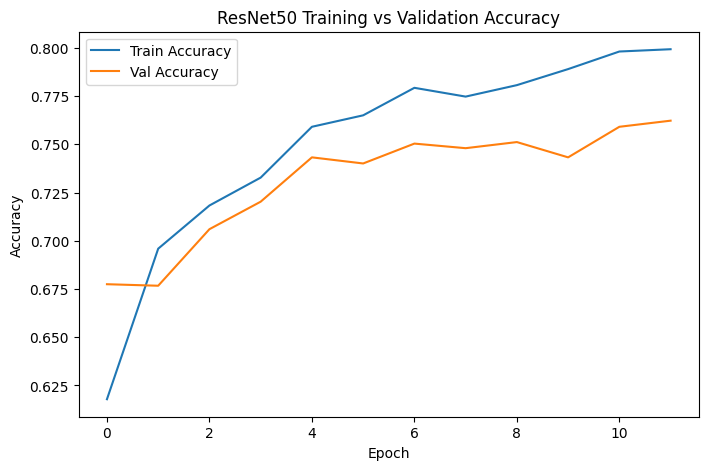

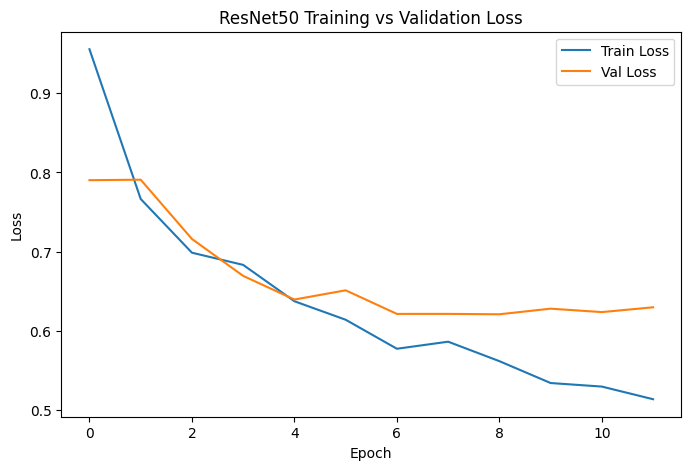

In [44]:
#Plotting validation and training accuracy and loss to monitor model performance during training
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history2.history["accuracy"], label="Train Accuracy")
plt.plot(history2.history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history2.history["loss"], label="Train Loss")
plt.plot(history2.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training vs Validation Loss")
plt.legend()
plt.show()

# Phase 2: Cross-Country Generalization (China and Russia)

In [17]:
import pandas as pd

gppd = pd.read_csv("global_power_plant_database.csv") #Importing WRI data to eventually extract plant information for patch creation and fuel-type labels

print(gppd.shape)
print(gppd.columns)

(34936, 36)
Index(['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw',
       'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2',
       'other_fuel3', 'commissioning_year', 'owner', 'source', 'url',
       'geolocation_source', 'wepp_id', 'year_of_capacity_data',
       'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015',
       'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018',
       'generation_gwh_2019', 'generation_data_source',
       'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014',
       'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016',
       'estimated_generation_gwh_2017', 'estimated_generation_note_2013',
       'estimated_generation_note_2014', 'estimated_generation_note_2015',
       'estimated_generation_note_2016', 'estimated_generation_note_2017'],
      dtype='object')


/tmp/ipykernel_7253/1553065950.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  gppd = pd.read_csv("global_power_plant_database.csv") #Importing WRI data to eventually extract plant information for patch creation and fuel-type labels


In [18]:
rc = gppd[gppd["country"].isin(["RUS", "CHN"])].copy() #Filtering data to only include Russia and China

print(rc.shape)
print(rc["country"].value_counts())

(4780, 36)
country
CHN    4235
RUS     545
Name: count, dtype: int64


In [19]:
fuel_map = { #Ensuring labels are consistent with training data labels
    "Hydro": "Hydro",
    "Gas": "Natural Gas",
    "Solar": "Solar",
    "Wind": "Wind"
}

rc["label"] = rc["primary_fuel"].map(fuel_map)
rc = rc[rc["label"].notna()].copy()

print(rc["label"].value_counts())
print(rc["country"].value_counts())

label
Solar          1375
Hydro          1052
Wind            838
Natural Gas     428
Name: count, dtype: int64
country
CHN    3270
RUS     423
Name: count, dtype: int64


In [20]:
rc = rc[rc["capacity_mw"] >= 50].copy() #Maintaining only larger plants to ensure visibility in images with resolution constraints

print("After capacity filter:") #Checking how much data for each class is available
print(rc["label"].value_counts())
print(rc["country"].value_counts())

After capacity filter:
label
Hydro          415
Solar          337
Natural Gas    254
Wind            83
Name: count, dtype: int64
country
CHN    844
RUS    245
Name: count, dtype: int64


In [21]:
#Cleaning Russia/China data, resetting indices and saving as separate CSVs by country in environment
rc_clean = rc.reset_index(drop=True)
rc_clean["id"] = rc_clean.index

rc_clean = rc_clean[["id", "country", "name", "latitude", "longitude", "label"]] #Reordering columns

russia_df = rc_clean[rc_clean["country"] == "RUS"].copy() #Splitting data into Russia and China dataframes
china_df  = rc_clean[rc_clean["country"] == "CHN"].copy()

russia_df.to_csv("russia_clean.csv", index=False) #Saving the data as separate CSVs
china_df.to_csv("china_clean.csv", index=False)

print(russia_df.head())
print(china_df.head())

      id country                         name  latitude  longitude  \
844  844     RUS  Adler Thermal Power Station   43.4202    39.9492   
845  845     RUS                 Akhtubinsky    48.4050    46.2350   
846  846     RUS               Amurskaya CHPP   50.2274   136.8821   
847  847     RUS                  Anadyr CHPP   64.7305   177.4995   
848  848     RUS             Arkhangelsk CHPP   64.5753    40.5731   

           label  
844  Natural Gas  
845        Solar  
846  Natural Gas  
847  Natural Gas  
848  Natural Gas  
   id country                          name  latitude  longitude  label
0   0     CHN  Aba Minjiang River Jiangseba   31.4837   103.6032  Hydro
1   1     CHN                          Ahai   27.3488   100.5061  Hydro
2   2     CHN                   Alashan 1p1   38.8950   105.6480  Solar
3   3     CHN                   Alashan 1p2   38.7610   105.7230  Solar
4   4     CHN                   Alashan 1p3   38.9300   105.6400  Solar


In [ ]:
#Test Sample
#russia_df = pd.read_csv("russia_clean.csv") #Creating a test sample to ensure patches were created, about 10 images per fuel type
#china_df = pd.read_csv("china_clean.csv")

#sample_per_class = 10

#russia_sample = (
 #   russia_df.groupby("label", group_keys=False)
 # .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=33))
 #   .reset_index(drop=True)
#)

#china_sample = (
 #   china_df.groupby("label", group_keys=False)
 #   .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=33))
 #   .reset_index(drop=True)
#)

#test_sample = pd.concat([russia_sample, china_sample], ignore_index=True)

#print(test_sample[["country", "label"]].value_counts())
#test_sample.head()

country  label     
CHN      Hydro         10
         NaturalGas    10
         Solar         10
         Wind          10
RUS      Hydro         10
         NaturalGas    10
         Solar          3
Name: count, dtype: int64


/tmp/ipykernel_3308/1772961050.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=33))
/tmp/ipykernel_3308/1772961050.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), sample_per_class), random_state=33))


,id,country,name,latitude,longitude,label
0,1026,RUS,Svetogorskaya HPP,61.1044,28.8394,Hydro
1,883,RUS,Chirkey HPP,42.9772,46.8708,Hydro
2,908,RUS,Irganayskaya HPP,42.7452,46.8316,Hydro
3,955,RUS,Narva HPP,59.3678,28.2106,Hydro
4,885,RUS,Dagestan Branch,46.8712,46.8712,Hydro


In [22]:
russia_df = pd.read_csv("russia_clean.csv") #Loading CSV files back
china_df = pd.read_csv("china_clean.csv")

test_data = pd.concat([russia_df, china_df], ignore_index=True) #Creating the testing set

print(test_data[["country", "label"]].value_counts())
print("Total test images:", len(test_data))
test_data.head()

country  label      
CHN      Hydro          356
         Solar          334
RUS      Natural Gas    183
CHN      Wind            83
         Natural Gas     71
RUS      Hydro           59
         Solar            3
Name: count, dtype: int64
Total test images: 1089


,id,country,name,latitude,longitude,label
0,844,RUS,Adler Thermal Power Station,43.4202,39.9492,Natural Gas
1,845,RUS,Akhtubinsky,48.4050,46.2350,Solar
2,846,RUS,Amurskaya CHPP,50.2274,136.8821,Natural Gas
3,847,RUS,Anadyr CHPP,64.7305,177.4995,Natural Gas
4,848,RUS,Arkhangelsk CHPP,64.5753,40.5731,Natural Gas


In [23]:
!pip install geemap -q #Installing Google Earth Engine for pulling of Satellite Imagery

In [24]:
import ee #Importing the earth engine

ee.Authenticate() #Connecting Python to Google Earth Engine
ee.Initialize(project="powerplant-projects") #Linking to specific project I created in Google to allow for queries

print("EE initialized successfully!")

EE initialized successfully!


In [25]:
#Pulling and creating the Sentinel-2 patches, defining the function that will allow us to automate this process
import os
import requests
import time
from tqdm import tqdm
import pandas as pd
import ee

out_dir = "/content/russia_china_sentinel_patches" #Defining a file pith for outputs
os.makedirs(out_dir, exist_ok=True)

def get_sentinel_rgb_patch(lat, lon, out_path, start_date="2022-01-01", end_date="2025-01-01"): #Getting RGB (triband) patches for specific coordinates and date ranges
    point = ee.Geometry.Point([lon, lat])

    # Sentinel-2 RGB is 10m/pixel (1km by 1km)...
    region = point.buffer(500).bounds()

    collection = ( #Pulling Sentinel-2 imagery that is atmospherically controlled for cloud coverage and specific dates
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(point)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )

    def scale_rgb(img): #Image scaling and color band selection
        rgb = img.select(["B4", "B3", "B2"]).divide(10000)
        return rgb.copyProperties(img, img.propertyNames())

    composite = collection.map(scale_rgb).median() #Creating the patches with the scaled images and medians of the selected photos from date range

    vis = composite.visualize( #Creating the image and scaling pixel values
        bands=["B4", "B3", "B2"],
        min=0.0,
        max=0.3
    )

    url = vis.getThumbURL({ #Selecting speccific size for CNN and formatting as a PNG for input
        "region": region,
        "dimensions": 224,
        "format": "png"
    })

    response = requests.get(url, timeout=60) #Sends the request and downloads the image

#Creating if-else to track status and failures
    if response.status_code == 200:
        with open(out_path, "wb") as f:
            f.write(response.content)
        return True
    else:
        print("Failed:", response.status_code, response.text[:200])
        return False

In [26]:
records = [] #Automating the creation of the dataset, calling our function 'get_sentinel_rgb_patch'

for _, row in tqdm(test_data.iterrows(), total=len(test_data)): #Iterating across the test data to retrieve identification information and pull patches
    img_id = row["id"]
    label = row["label"]
    country = row["country"]
    lat = row["latitude"]
    lon = row["longitude"]

    fname = f"{img_id}_{country}_{label}.png"
    out_path = os.path.join(out_dir, fname)

    try:
        success = get_sentinel_rgb_patch(lat, lon, out_path)

        if success:
            records.append({
                "id": img_id,
                "country": country,
                "name": row.get("name", ""),
                "latitude": lat,
                "longitude": lon,
                "label": label,
                "image_path": out_path
            })

        time.sleep(0.5)

    except Exception as e:
        print("Skipped:", img_id, "|", e)

patch_df = pd.DataFrame(records)
patch_df.to_csv("russia_china_sentinel_patch_manifest.csv", index=False)

print("Images created:", len(patch_df))
print(patch_df[["country", "label"]].value_counts())
patch_df.head()

100%|██████████| 1089/1089 [1:33:31<00:00,  5.15s/it]

Images created: 1089
country  label      
CHN      Hydro          356
         Solar          334
RUS      Natural Gas    183
CHN      Wind            83
         Natural Gas     71
RUS      Hydro           59
         Solar            3
Name: count, dtype: int64


,id,country,name,latitude,longitude,label,image_path
0,844,RUS,Adler Thermal Power Station,43.4202,39.9492,Natural Gas,/content/russia_china_sentinel_patches/844_RUS...
1,845,RUS,Akhtubinsky,48.4050,46.2350,Solar,/content/russia_china_sentinel_patches/845_RUS...
2,846,RUS,Amurskaya CHPP,50.2274,136.8821,Natural Gas,/content/russia_china_sentinel_patches/846_RUS...
3,847,RUS,Anadyr CHPP,64.7305,177.4995,Natural Gas,/content/russia_china_sentinel_patches/847_RUS...
4,848,RUS,Arkhangelsk CHPP,64.5753,40.5731,Natural Gas,/content/russia_china_sentinel_patches/848_RUS...


In [27]:
!zip -r /content/patches_backup.zip /content/russia_china_sentinel_patches

  adding: content/russia_china_sentinel_patches/ (stored 0%)
  adding: content/russia_china_sentinel_patches/80_CHN_Hydro.png (deflated 1%)
  adding: content/russia_china_sentinel_patches/1024_RUS_Natural Gas.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/392_CHN_Solar.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/77_CHN_Hydro.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/441_CHN_Hydro.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/760_CHN_Solar.png (deflated 1%)
  adding: content/russia_china_sentinel_patches/436_CHN_Hydro.png (deflated 1%)
  adding: content/russia_china_sentinel_patches/242_CHN_Solar.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/92_CHN_Solar.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/15_CHN_Hydro.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/642_CHN_Solar.png (deflated 0%)
  adding: content/russia_china_sentinel_patches/1006_RUS

In [28]:
from google.colab import files
files.download('/content/patches_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

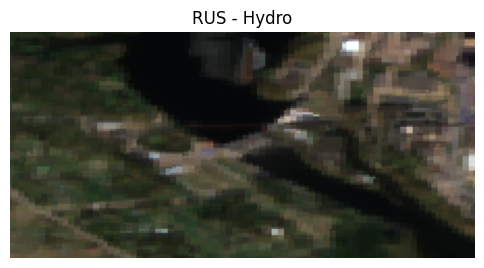

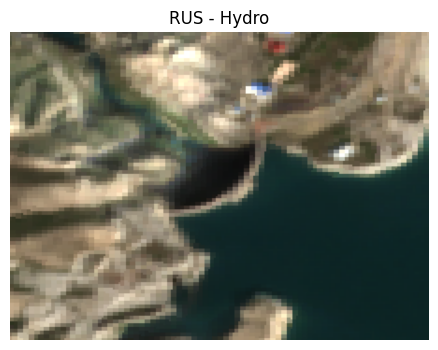

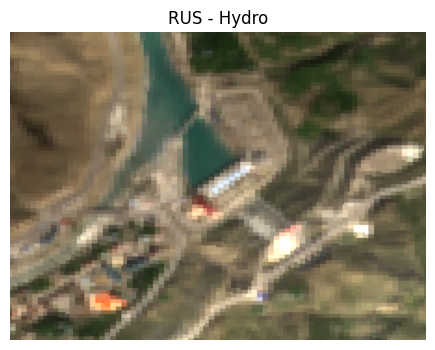

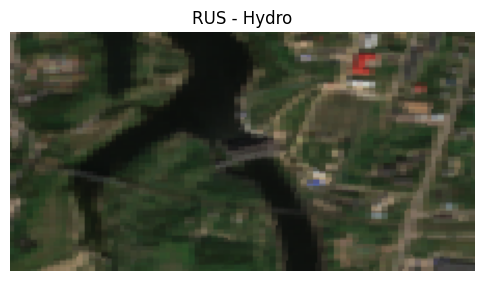

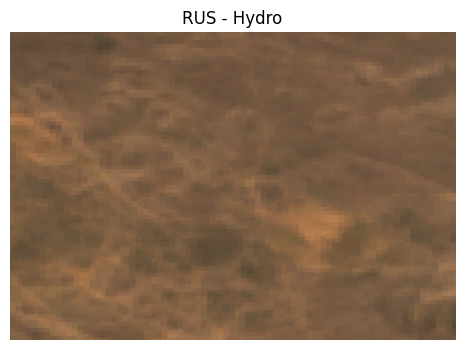

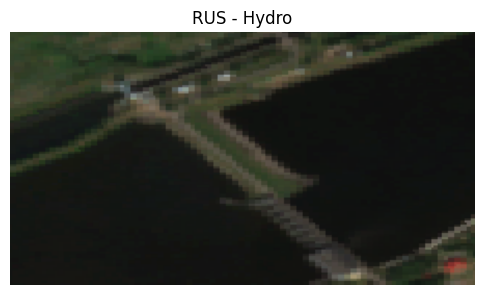

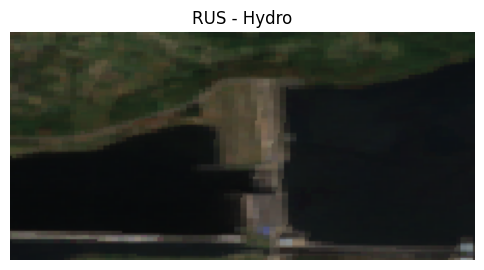

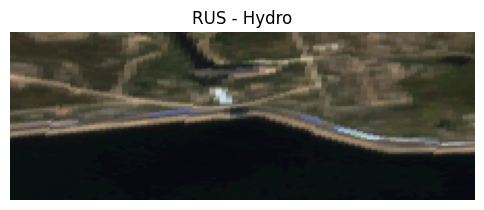

In [ ]:
#import matplotlib.pyplot as plt #Checking images loaded, use only with test sample to avoid overload and bottlenecks in running
#from PIL import Image

#for i in range(min(8, len(patch_df))):
 #   img = Image.open(patch_df.iloc[i]["image_path"])
 #   plt.figure(figsize=(6, 4))
 #   plt.imshow(img)
 #   plt.title(f"{patch_df.iloc[i]['country']} - {patch_df.iloc[i]['label']}")
 #   plt.axis("off")
 #   plt.show()

In [46]:
#Evaluating the performance of the selected model on the constructed image dataset
test_datagen = ImageDataGenerator( #Creating a test data generator to normalize and scale images
    preprocessing_function=preprocess_input
)

test_gen = test_datagen.flow_from_dataframe( #Batching the test data to allow for efficient data proccessing (feeds the model 32 images at a time)
    dataframe=patch_df,
    x_col="image_path",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=["Hydro", "Natural Gas", "Solar", "Wind"],
    shuffle=False
)

loss, acc = model2.evaluate(test_gen) #Evaluating 'model2' performance on the data using loss and accuracy metrics

print(f"Russia/China Accuracy: {acc:.4f}")
print(f"Russia/China Loss: {loss:.4f}")

Found 1089 validated image filenames belonging to 4 classes.
35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.5693 - loss: 1.3785
Russia/China Accuracy: 0.5693
Russia/China Loss: 1.3785


In [47]:
import numpy as np #Retrieving model2 precision, recall, and f1-score for detailed evaluation of model performance
from sklearn.metrics import classification_report, confusion_matrix

test_gen.reset()

pred_probs = model2.predict(test_gen)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_gen.classes

print(classification_report(
    true_labels,
    pred_labels,
    target_names=["Hydro", "Natural Gas", "Solar", "Wind"]
))

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step
              precision    recall  f1-score   support

       Hydro       0.95      0.38      0.54       415
 Natural Gas       0.68      0.83      0.75       254
       Solar       0.69      0.63      0.66       337
        Wind       0.13      0.49      0.21        83

    accuracy                           0.57      1089
   macro avg       0.61      0.58      0.54      1089
weighted avg       0.75      0.57      0.60      1089



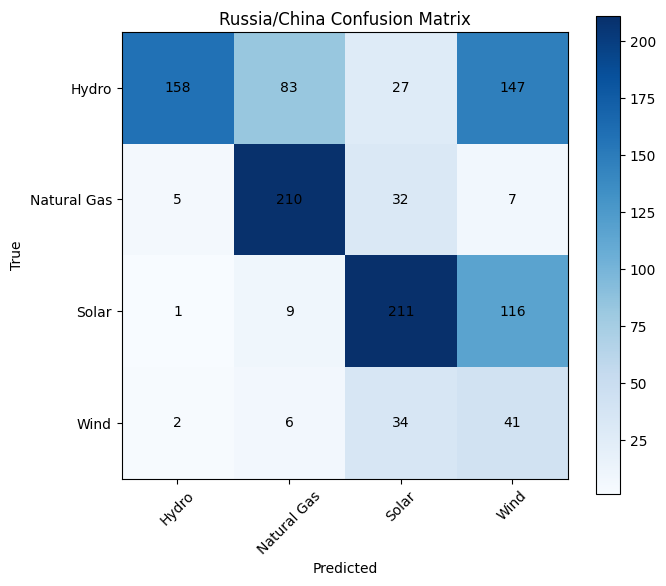

In [57]:
#Generating a confusion matrix for test data to understand how 'model2' handled classes of global plants
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)
classes = ["Hydro", "Natural Gas", "Solar", "Wind"]

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Russia/China Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


# Phase 3: Creating Interactive Leaflet Map for Visualization


In [49]:
import numpy as np

preds = model2.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

# map back to labels
class_names = list(test_gen.class_indices.keys())
patch_df["pred_label"] = [class_names[i] for i in y_pred]

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step


In [58]:
#Building folium map with legend, title, color-coded dots, and interactive labeling feature
import folium

m = folium.Map(
    location=[patch_df["latitude"].mean(), patch_df["longitude"].mean()],
    zoom_start=3
)

color_map = {
    "Solar": "orange",
    "Wind": "green",
    "Hydro": "blue",
    "Natural Gas": "red"
}

for _, row in patch_df.iterrows():
    popup_text = f"""
    <b>Prediction:</b> {row['pred_label']}<br>
    <b>Ground Truth:</b> {row['label']}<br>
    <b>Country:</b> {row.get('country', '')}<br>
    <b>Plant:</b> {row.get('name', '')}
    """

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=color_map.get(row["pred_label"], "gray"),
        fill=True,
        fill_color=color_map.get(row["pred_label"], "gray"),
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=300)
    ).add_to(m)

title_html = '''
<h3 align="center" style="font-size:20px"><b>Power Plant Predictions (Russia & China)</b></h3>
'''
m.get_root().html.add_child(folium.Element(title_html))

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 180px; height: 160px;
    background-color: white; z-index:9999; font-size:14px;
    border:2px solid grey; border-radius:5px; padding: 10px;
">
<b>Legend</b><br>
<i style="color:blue;">●</i> Hydro<br>
<i style="color:red;">●</i> Natural Gas<br>
<i style="color:orange;">●</i> Solar<br>
<i style="color:green;">●</i> Wind<br>
<i style="color:gray;">●</i> Other/Unknown<br>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

m